<a href="https://colab.research.google.com/github/AymaneAmri-MD/drug-design-morphine-paclitaxel/blob/main/01_ligand_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -q rdkit
!git clone -q https://github.com/AymaneAmri-MD/drug-design-morphine-paclitaxel.git
%cd drug-design-morphine-paclitaxel/notebooks
import os; os.makedirs('../results', exist_ok=True)

/content/drug-design-morphine-paclitaxel/notebooks/drug-design-morphine-paclitaxel/notebooks


# 01 · Préparation des ligands
Morphine et paclitaxel : SMILES, stéréochimie, descripteurs, conformères 3D.

**Important :** les SMILES ci-dessous sont à *vérifier* (par ex. sur PubChem) avant usage, en particulier la stéréochimie.

In [11]:
import sys; sys.path.append('../src')
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from ligand_prep import load_mol, describe, embed_conformers, write_best_conformer

## Définition des ligands
SMILES isomériques (avec stéréochimie), à recopier depuis PubChem (CID 5288826 pour la morphine, CID 36314 pour le paclitaxel).

In [14]:
import requests

def pubchem_smiles(cid):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/IsomericSMILES/TXT"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.text.strip()

ligands = {
    'morphine': pubchem_smiles(5288826),
    'paclitaxel': pubchem_smiles(36314),
}
for k, v in ligands.items():
    print(k, '->', v)

morphine -> CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@H]3[C@H](C=C4)O
paclitaxel -> CC1=C2[C@H](C(=O)[C@@]3([C@H](C[C@@H]4[C@]([C@H]3[C@@H]([C@@](C2(C)C)(C[C@@H]1OC(=O)[C@@H]([C@H](C5=CC=CC=C5)NC(=O)C6=CC=CC=C6)O)O)OC(=O)C7=CC=CC=C7)(CO4)OC(=O)C)O)C)OC(=O)C


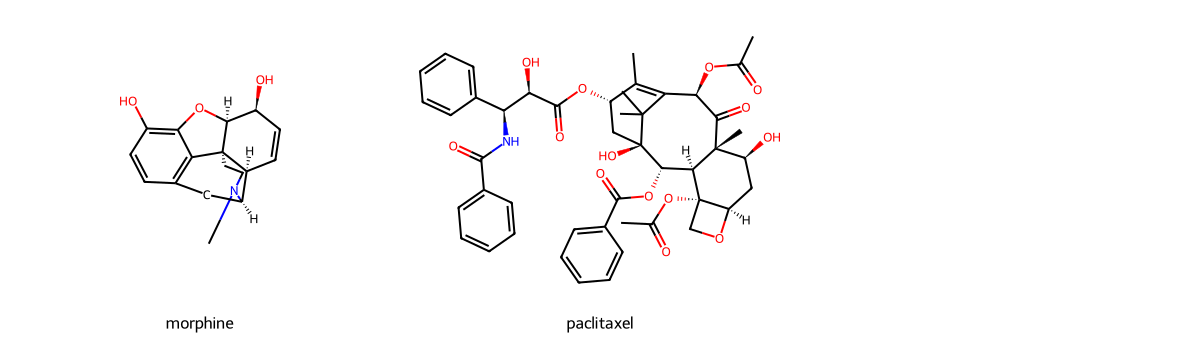

In [15]:
mols = {k: load_mol(v) for k, v in ligands.items()}
Draw.MolsToGridImage(list(mols.values()), legends=list(mols.keys()), subImgSize=(400, 350))

## Descripteurs
Vérifie le nombre de centres chiraux et la règle des 5 de Lipinski (le paclitaxel la viole largement, ce qui est attendu).

In [16]:
pd.DataFrame({k: describe(m) for k, m in mols.items()}).T

,formule,masse_molaire,logP,HBD,HBA,liaisons_rotatives,centres_chiraux
morphine,C17H19NO3,285.34,1.2,2,4,0,5
paclitaxel,C47H51NO14,853.92,3.74,4,14,10,11


## Conformères 3D
50 conformères par ligand, optimisation MMFF, seed fixé pour la reproductibilité.

In [17]:
for name, mol in mols.items():
    molh, ids, energies = embed_conformers(mol, n_confs=50)
    best = write_best_conformer(molh, energies, f'../results/{name}_best.mol')
    print(f'{name}: {len(ids)} conformères, meilleur = {best}, E = {min(energies):.1f} kcal/mol')

morphine: 50 conformères, meilleur = 35, E = 94.3 kcal/mol
paclitaxel: 50 conformères, meilleur = 6, E = 218.1 kcal/mol


## Étape suivante
`02_docking.ipynb` : re-docking du ligand co-cristallisé, puis docking morphine → récepteur µ et paclitaxel → tubuline.